In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

In [3]:
BASE = "/content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN/DARIEN"
DARIEN_MODELES = "/content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN"

In [4]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN"
darien_path = os.path.join(base_path, "DARIEN")
modele_path = {
    "tok2vec_enrichi": os.path.join(base_path, "resultats_tok2vec_enrichi"),
    "tok2vec_quaero_fusioné": os.path.join(base_path, "resultats_tok2vec_quaero_fusioné"),
    "tok2vec_initial": os.path.join(base_path, "resultats_tok2vec_initial")}

In [5]:
fichiers = {
    "REF": {
        "spacy": f"{darien_path}/REF/DARIEN_Le-voleur_REF.txt_spacy-lg-3.7.5.json",
        "flair": f"{darien_path}/REF/DARIEN_Le-voleur_REF.txt_flair-0.13.1.json",
        "camembert": f"{darien_path}/REF/DARIEN_Le-voleur_REF.txt_camembert-4.41.1.json",
        "tok2vec_enrichi": f"{modele_path['tok2vec_enrichi']}/DARIEN_Le-voleur_REF_tok2vec_enrichi.json",
        "tok2vec_quaero_fusioné": f"{modele_path['tok2vec_quaero_fusioné']}/DARIEN_Le-voleur_REF_tok2vec_quaero_fusioné.json",
        "tok2vec_initial": f"{modele_path['tok2vec_initial']}/DARIEN_Le-voleur_REF_tok2vec_initial.json",
    },
    "TESSERACT": {
        "spacy": f"{darien_path}/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_spacy-lg-3.7.5.json",
        "flair": f"{darien_path}/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_flair-0.13.1.json",
        "camembert": f"{darien_path}/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_camembert-4.41.1.json",
        "tok2vec_enrichi": f"{modele_path['tok2vec_enrichi']}/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_enrichi.json",
        "tok2vec_quaero_fusioné": f"{modele_path['tok2vec_quaero_fusioné']}/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_quaero_fusioné.json",
        "tok2vec_initial": f"{modele_path['tok2vec_initial']}/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_initial.json",
    },
    "KRAKEN": {
        "spacy": f"{darien_path}/KRAKEN/DARIEN_Le-voleur_kraken4.3.13.dev25.txt_spacy-lg-3.7.5.json",
        "flair": f"{darien_path}/KRAKEN/DARIEN_Le-voleur_kraken4.3.13.dev25.txt_flair-0.13.1.json",
        "camembert": f"{darien_path}/KRAKEN/DARIEN_Le-voleur_kraken4.3.13.dev25.txt_camembert-4.41.1.json",
        "tok2vec_enrichi": f"{modele_path['tok2vec_enrichi']}/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_enrichi.json",
        "tok2vec_quaero_fusioné": f"{modele_path['tok2vec_quaero_fusioné']}/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_quaero_fusioné.json",
        "tok2vec_initial": f"{modele_path['tok2vec_initial']}/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_initial.json",
    }
}

**Nombre d'entités détectées par modèle**

In [6]:
def compter_entites(json_path):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            if isinstance(data, dict):
                return len(data)
            elif isinstance(data, list):
                return len(data)
            else:
                return 0
    except Exception as e:
        print(f"Erreur pour {json_path} : {e}")
        return 0

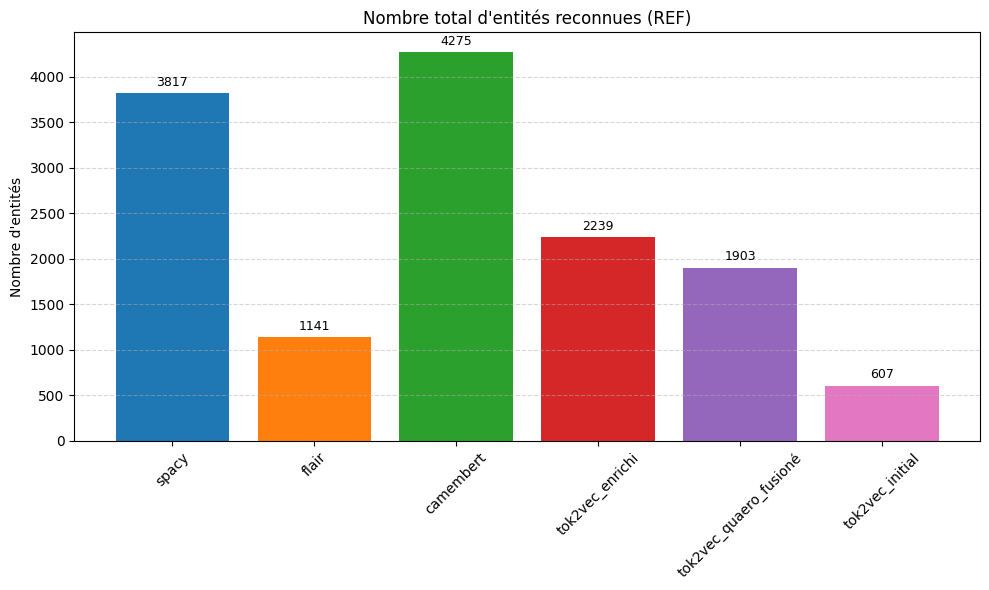

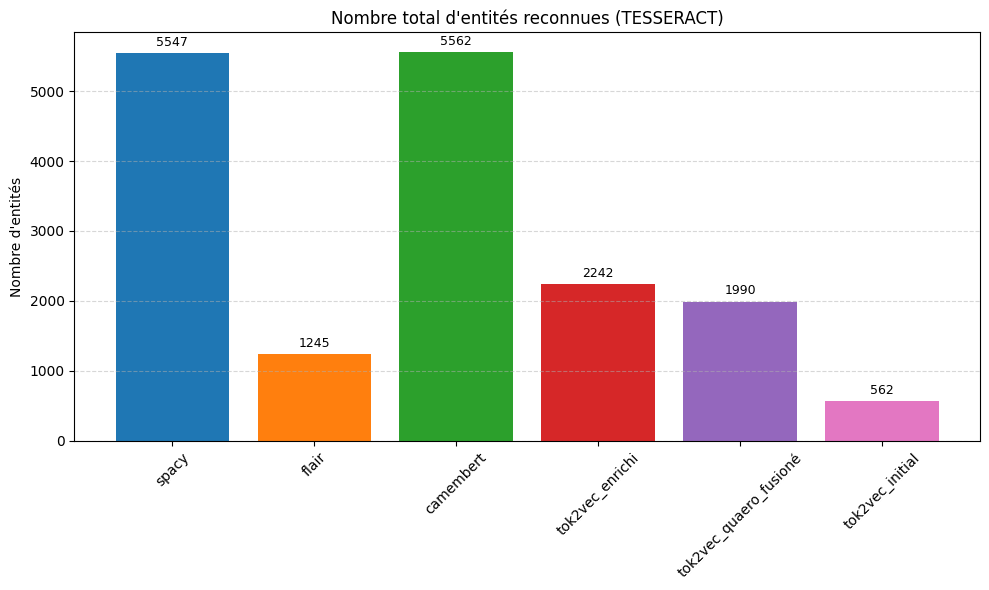

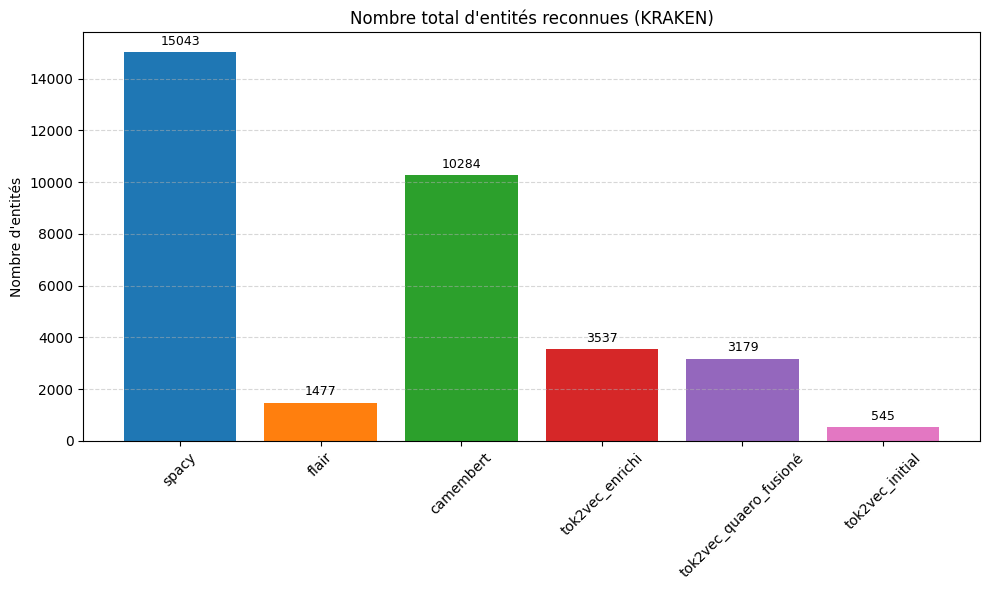

In [7]:
couleurs = {
    "spacy": "#1f77b4",   # bleu
    "flair": "#ff7f0e",   # orange
    "camembert": "#2ca02c",  # vert
    "tok2vec_enrichi": "#d62728",  # rouge
    "tok2vec_quaero_fusioné": "#9467bd",  # violet
    "tok2vec_initial": "#e377c2"  # rose
}

for source in ["REF", "TESSERACT", "KRAKEN"]:
    compte = {}
    for modele, path in fichiers[source].items():
        compte[modele] = compter_entites(path)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(compte.keys(), compte.values(), color=[couleurs[m] for m in compte.keys()])

    for bar in bars:
        hauteur = bar.get_height()
        plt.annotate(f"{hauteur}",
                     xy=(bar.get_x() + bar.get_width() / 2, hauteur),
                     xytext=(0, 3),  # décalage vertical
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, color='black')

    plt.xticks(rotation=45)
    plt.ylabel("Nombre d'entités")
    plt.title(f"Nombre total d'entités reconnues ({source})")
    plt.grid(axis='y', linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN/graphique_entites_{source}.png", dpi=300, bbox_inches="tight")
    plt.show()


**Analyse par type d'entité**

In [8]:
# Fonction pour normaliser les labels LOC avec suffixes
def normaliser_label(label):
    if label.startswith("LOC"):
        return "LOC"
    return label

# Fonction pour charger les entités depuis un fichier JSON et compter les types
def compter_par_type(json_path):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            if isinstance(data, dict):
                entites = data.values()
            elif isinstance(data, list):
                entites = data
            else:
                return Counter()

            cpt = Counter()
            for ent in entites:
                label = ent.get("label", "")
                if isinstance(label, list):
                    for l in label:
                        cpt[normaliser_label(l)] += 1
                elif isinstance(label, str):
                    for l in label.split(","):  # si plusieurs labels séparés par des virgules
                        cpt[normaliser_label(l.strip())] += 1
            return cpt
    except Exception as e:
        print(f"Erreur avec {json_path} : {e}")
        return Counter()

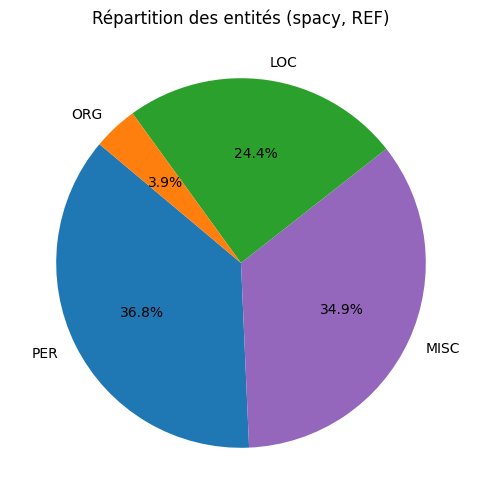

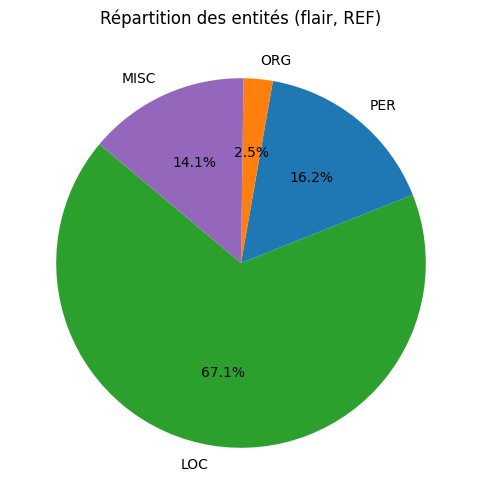

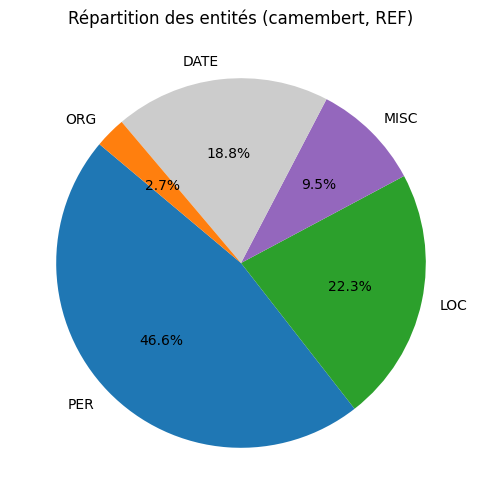

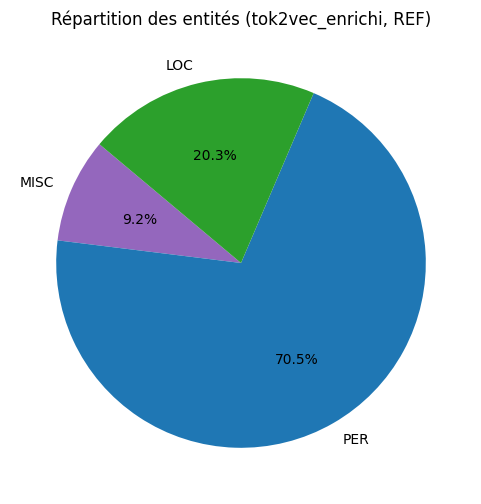

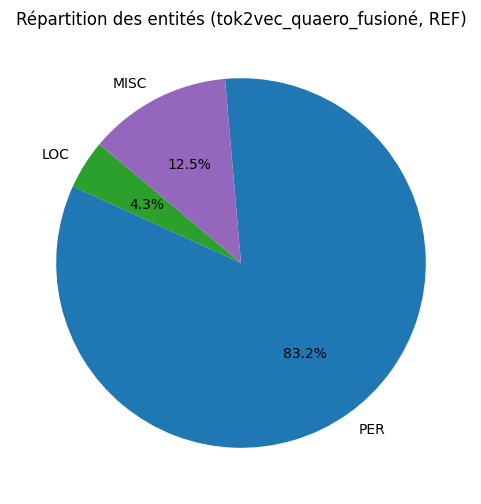

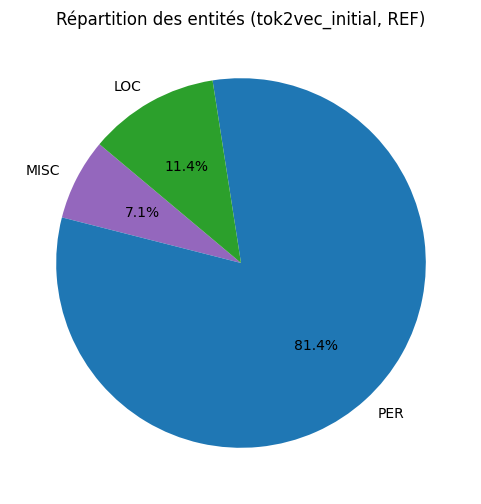

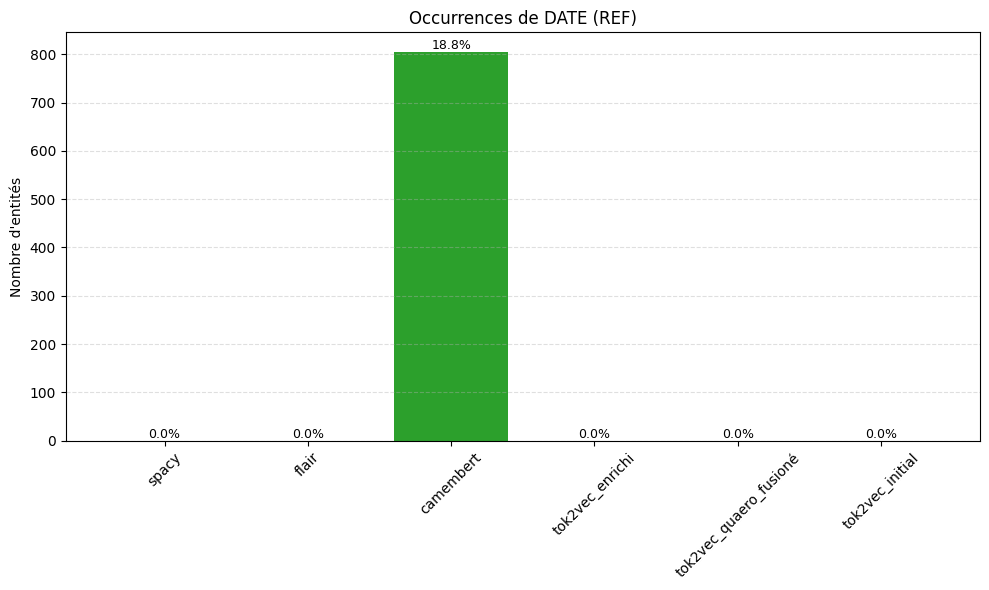

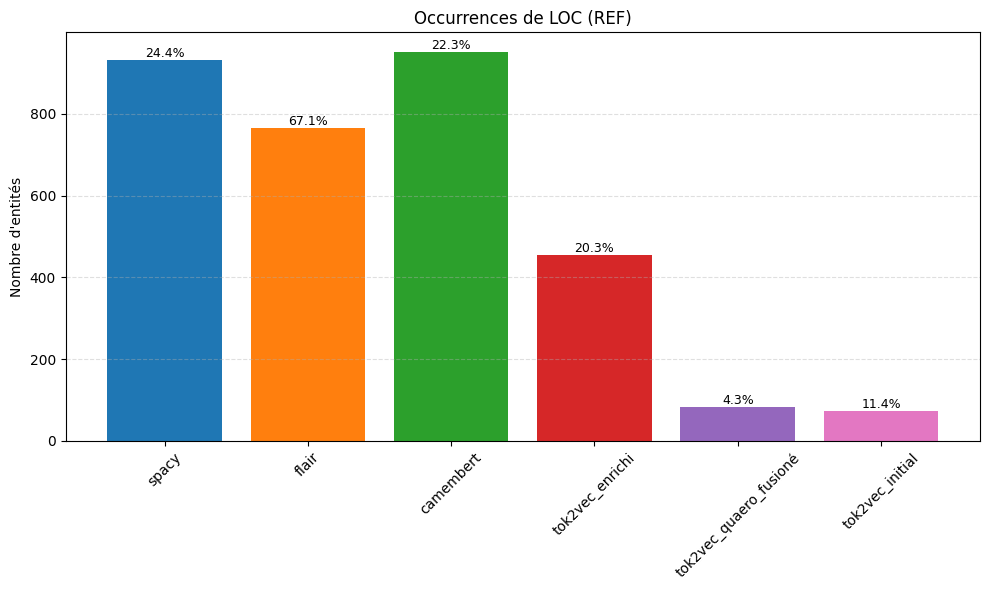

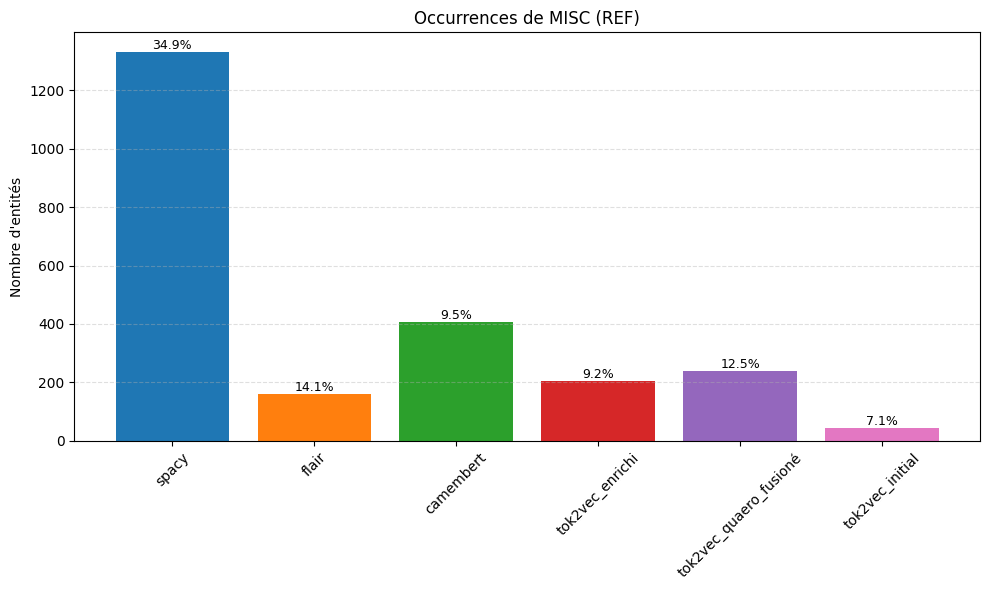

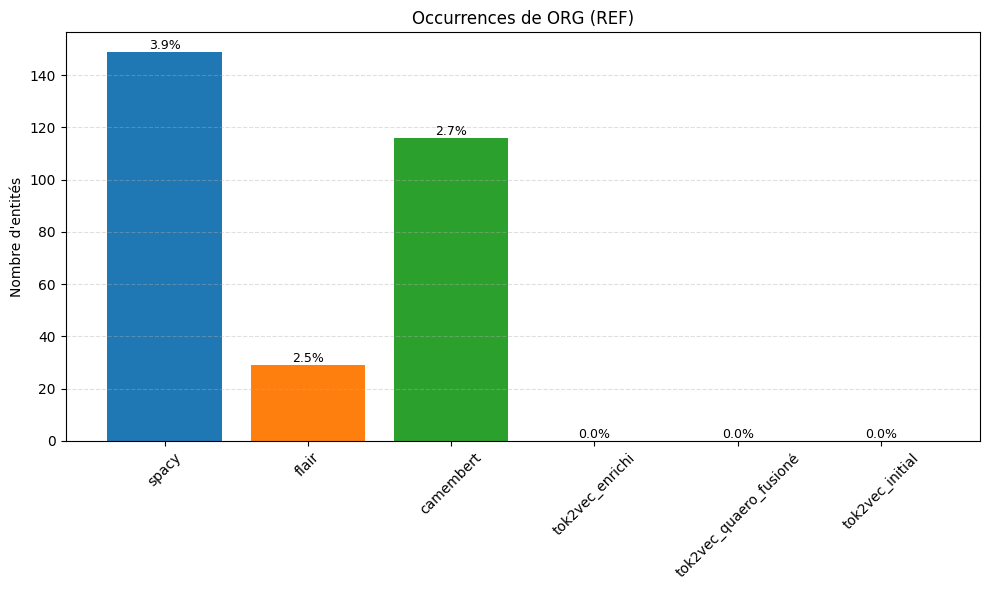

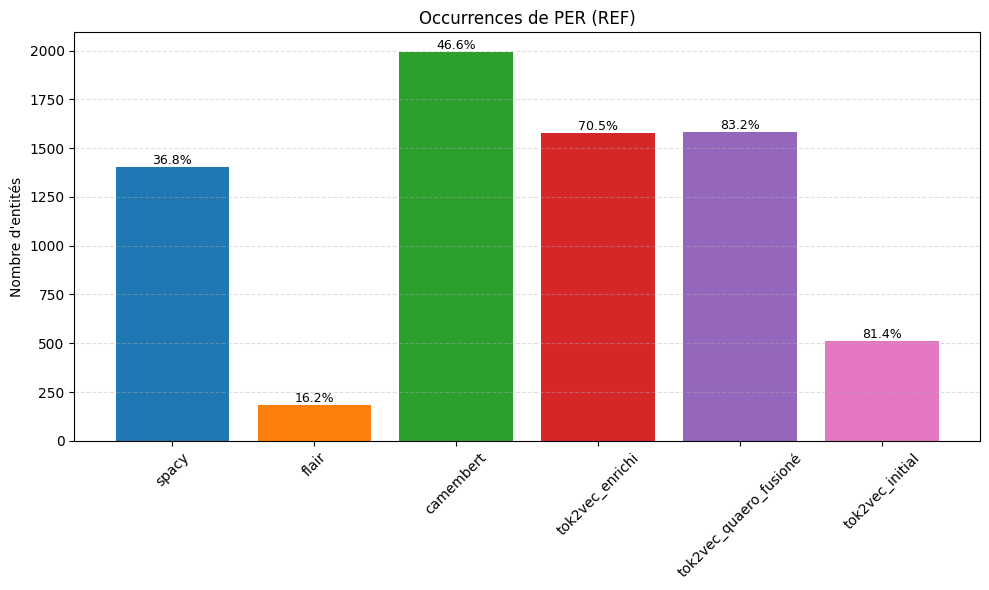

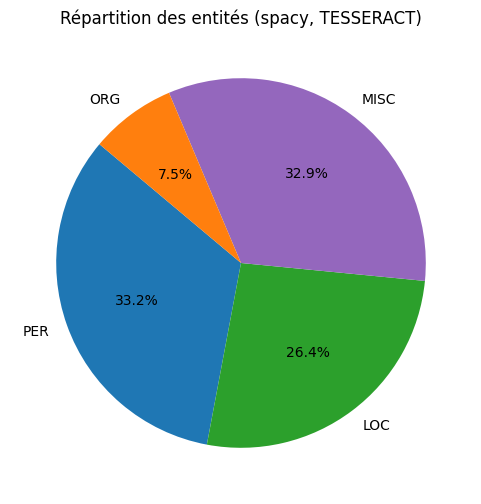

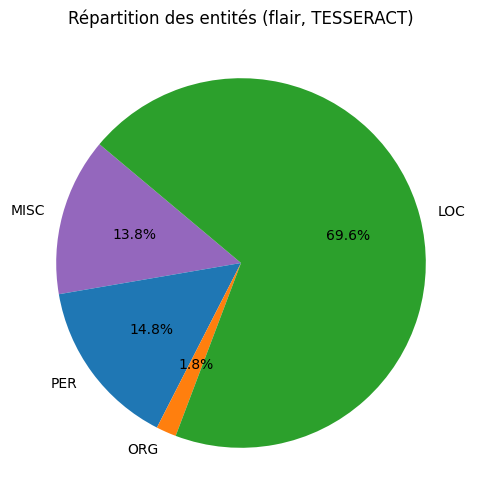

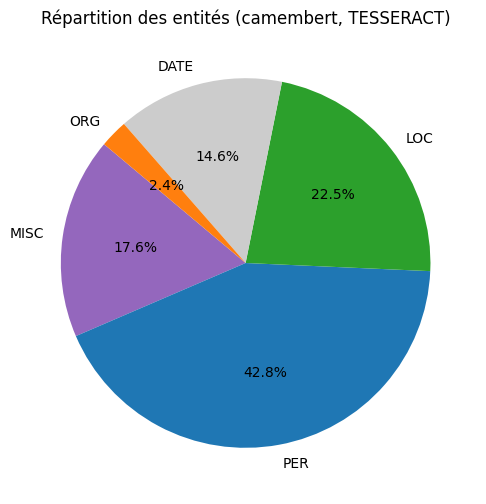

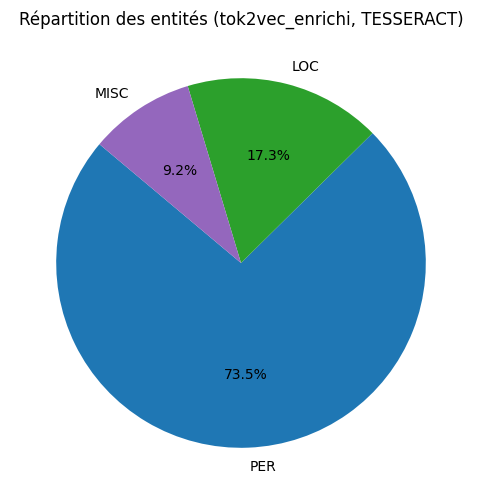

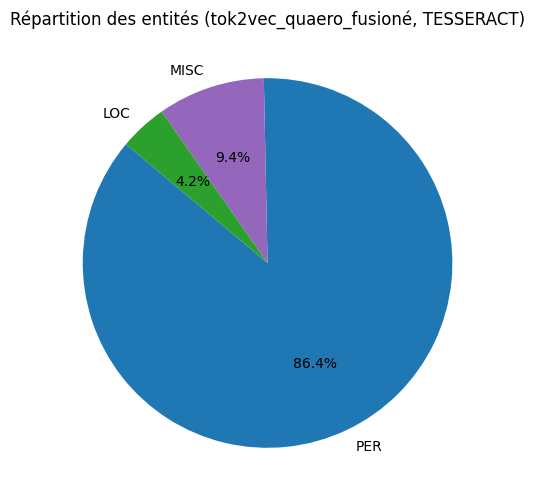

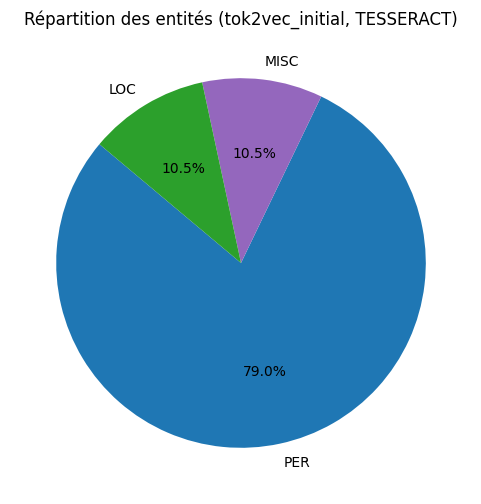

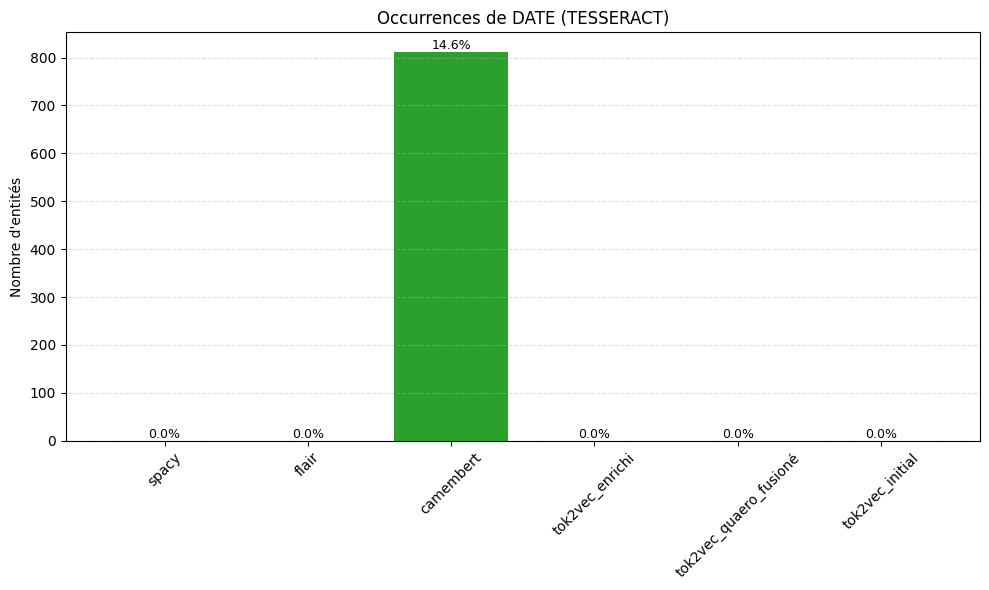

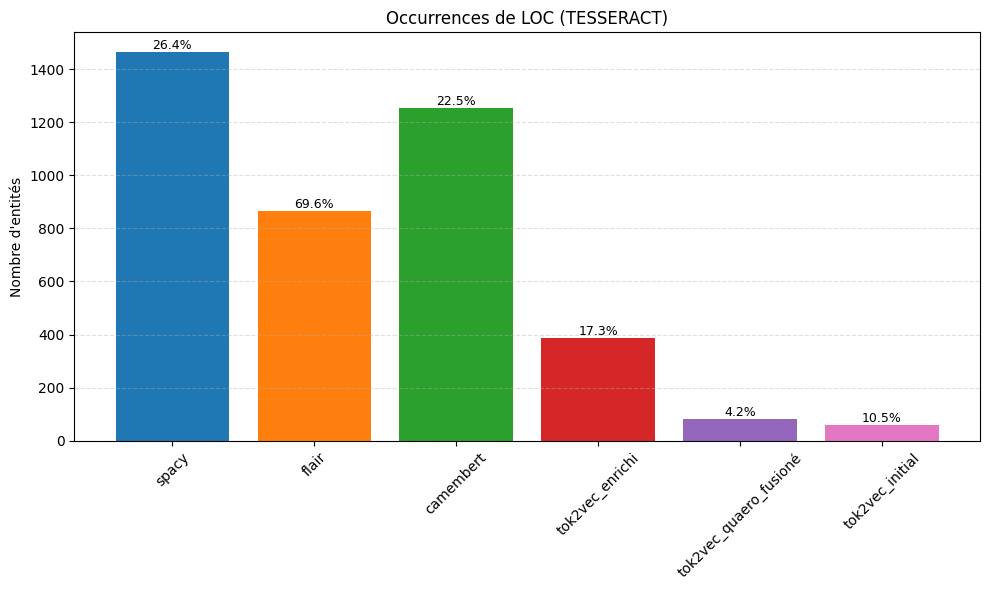

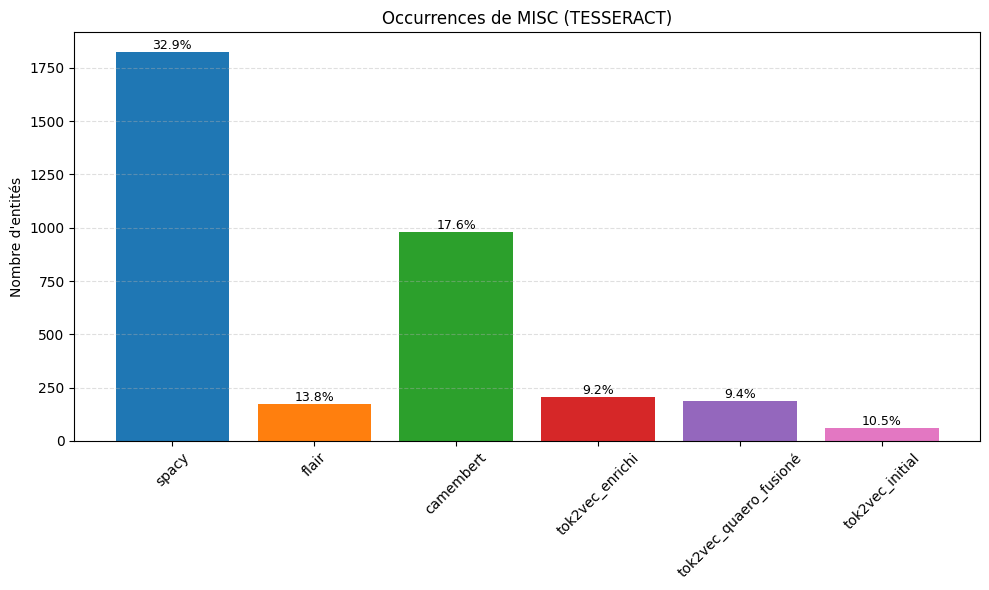

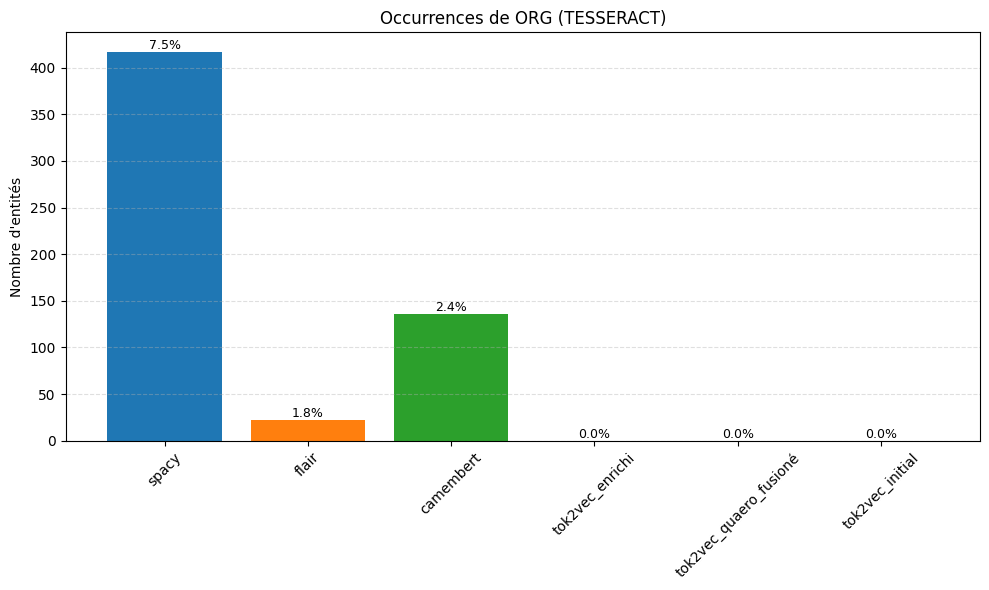

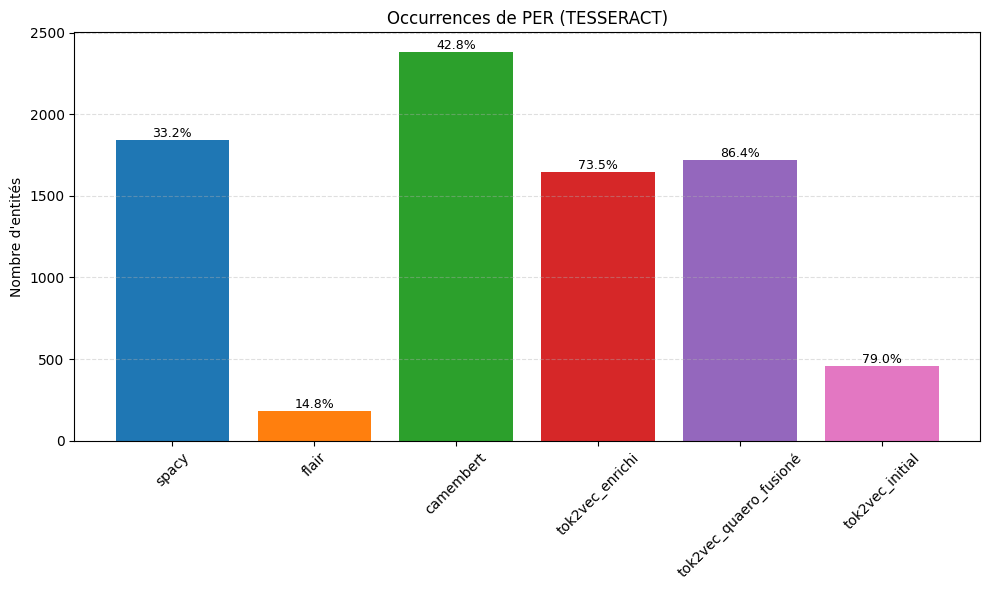

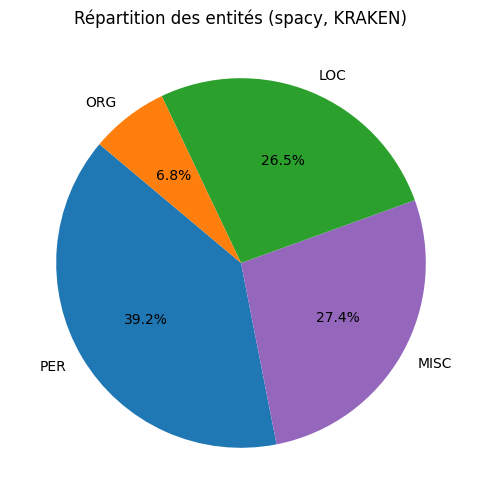

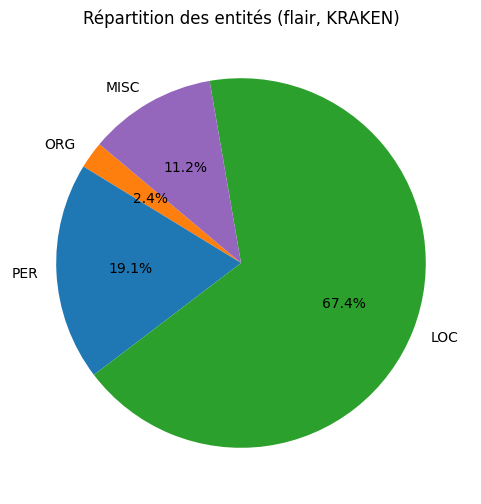

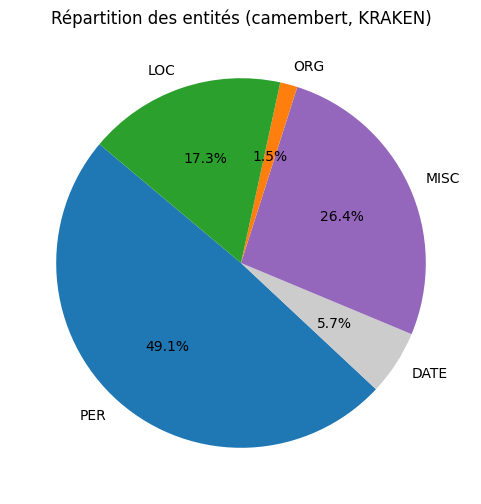

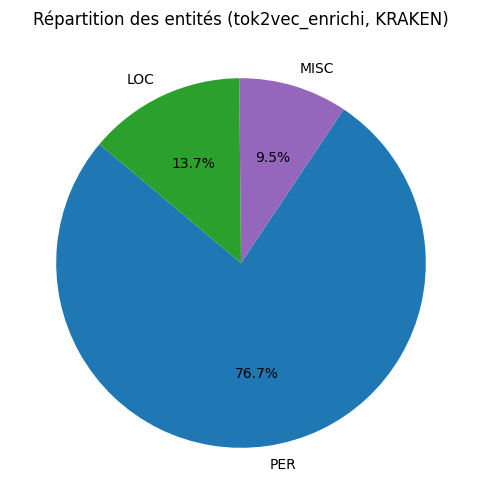

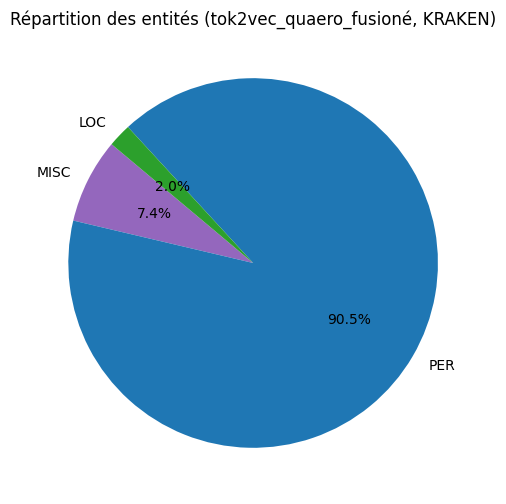

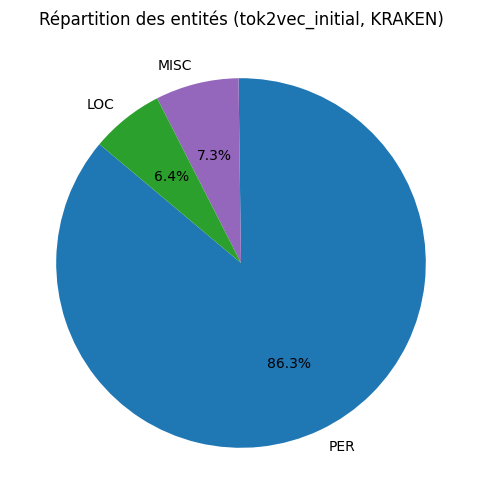

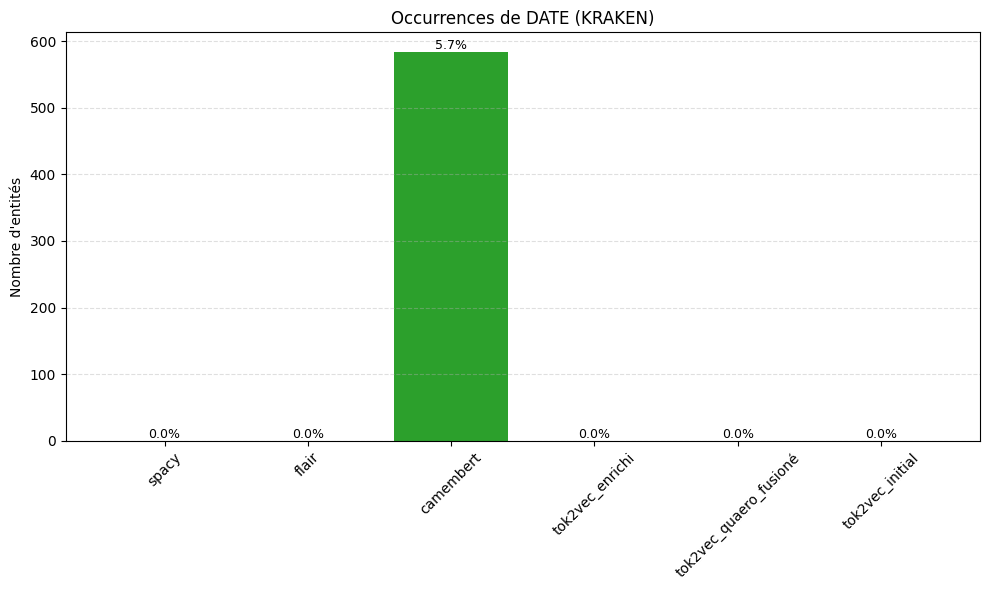

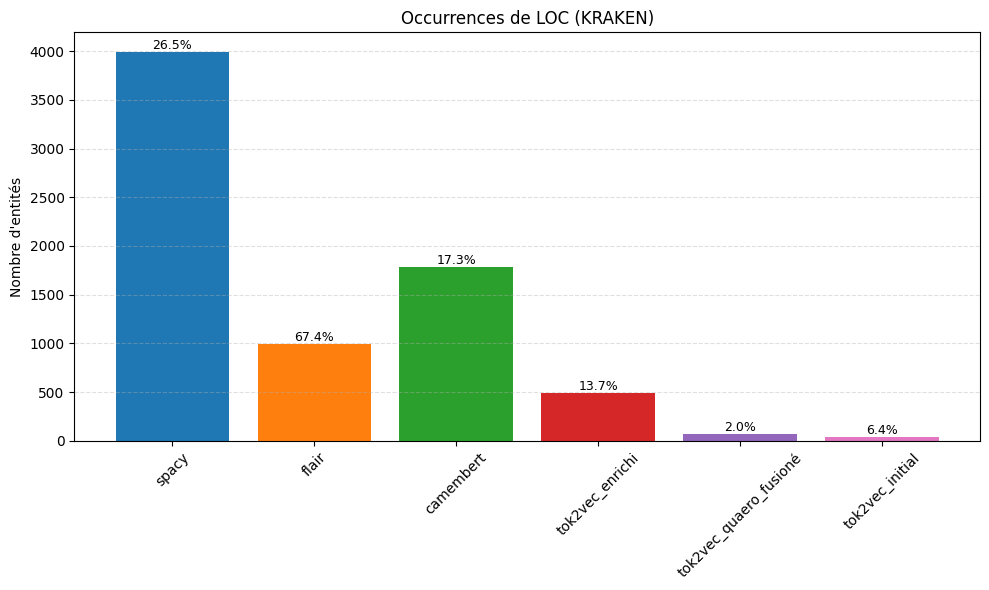

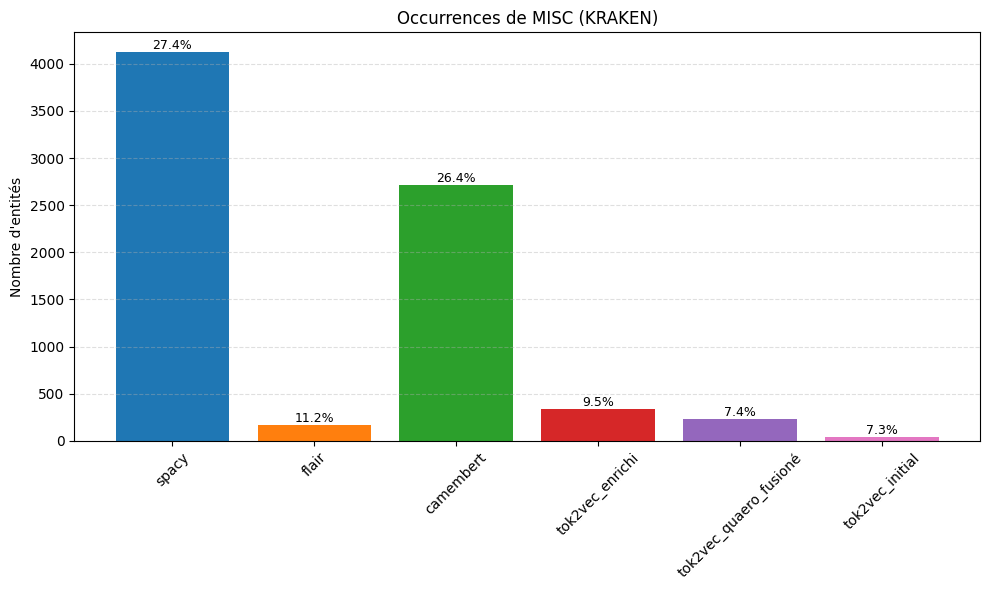

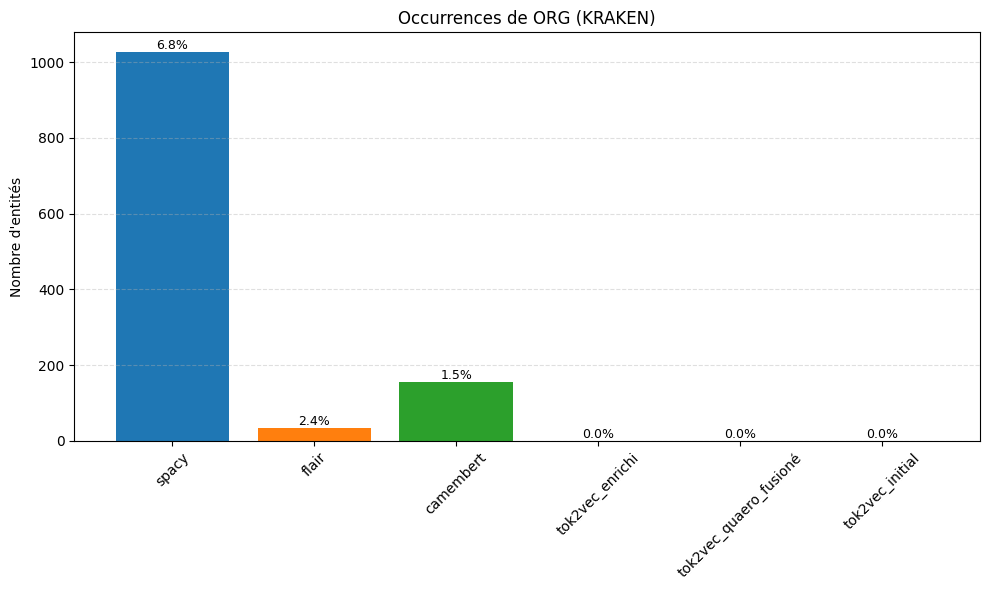

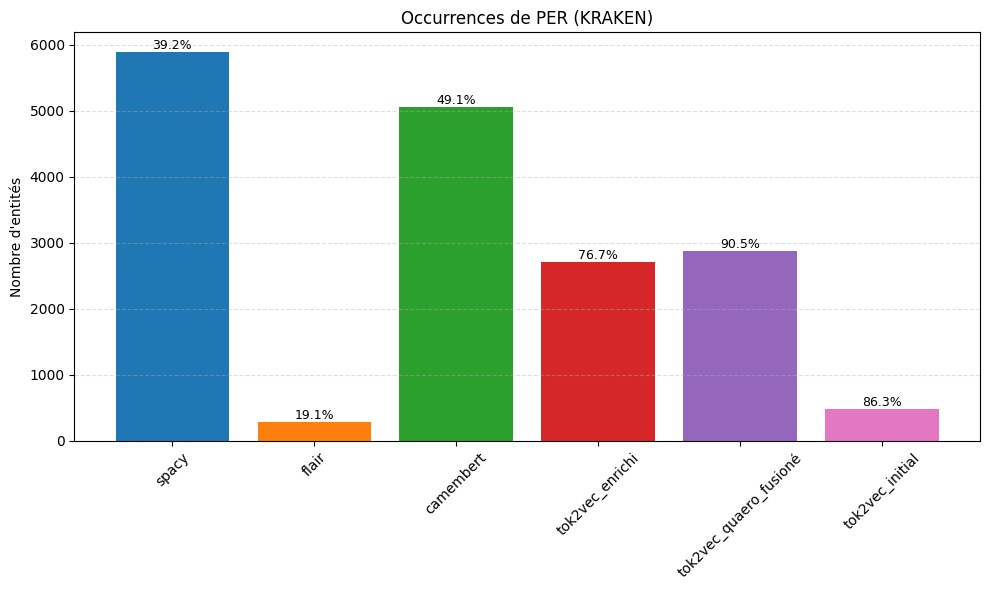

In [9]:
# Couleurs graphiques à barres
couleurs = {
    "spacy": "#1f77b4",   # bleu
    "flair": "#ff7f0e",   # orange
    "camembert": "#2ca02c",  # vert
    "tok2vec_enrichi": "#d62728",  # rouge
    "tok2vec_quaero_fusioné": "#9467bd",  # violet
    "tok2vec_initial": "#e377c2"  # rose
}

# Couleurs camemberts
couleurs_labels = {
    "PER": "#1f77b4",   # bleu
    "LOC": "#2ca02c",   # vert
    "ORG": "#ff7f0e",   # orange
    "MISC": "#9467bd"   # violet
}


for source in ["REF", "TESSERACT", "KRAKEN"]:
    # 1. Camemberts : un par modèle
    for modele, path in fichiers[source].items():
        cpt = compter_par_type(path)
        total = sum(cpt.values())
        if total == 0:
            continue

        plt.figure(figsize=(6, 6))
        labels = list(cpt.keys())
        valeurs = list(cpt.values())
        pourcentages = [f"{(v/total)*100:.1f}%" for v in valeurs]
        couleurs_camembert = [couleurs_labels.get(lab,"#cccccc") for lab in labels]
        plt.pie(valeurs, labels=labels, colors=couleurs_camembert, autopct='%1.1f%%', startangle=140)
        plt.title(f"Répartition des entités ({modele}, {source})")
        chemin = f"{base_path}/graph_pie_{source}_{modele}.png"
        plt.savefig(chemin, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    # 2. Barres : un par type d'entité (PER, LOC, ORG, etc.)
    # On rassemble tous les types d'EN rencontrés dans cette source
    tous_les_types = set()
    stats = defaultdict(dict)

    for modele, path in fichiers[source].items():
        cpt = compter_par_type(path)
        total = sum(cpt.values())
        for typ, nb in cpt.items():
            stats[typ][modele] = (nb, nb / total * 100 if total > 0 else 0)
            tous_les_types.add(typ)

    for ent_type in sorted(tous_les_types):
        plt.figure(figsize=(10, 6))
        modeles = list(fichiers[source].keys())
        valeurs = [stats.get(ent_type, {}).get(m, (0, 0))[0] for m in modeles]
        pourcentages = [stats.get(ent_type, {}).get(m, (0, 0))[1] for m in modeles]

        bars = plt.bar(modeles, valeurs, color=[couleurs[m] for m in modeles])
        for bar, pct in zip(bars, pourcentages):
            hauteur = bar.get_height()
            plt.annotate(f"{pct:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, hauteur),
                         ha='center', va='bottom', fontsize=9)

        plt.title(f"Occurrences de {ent_type} ({source})")
        plt.ylabel("Nombre d'entités")
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle="--", alpha=0.4)
        plt.tight_layout()
        chemin_bar = f"{base_path}/graph_bar_{source}_{ent_type}.png"
        plt.savefig(chemin_bar, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
